In [55]:
import tensorflow as tf 
from tensorflow import keras 
import matplotlib.pyplot as plt 
%matplotlib inline 
import numpy as np

In [56]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [57]:
len(X_train)

60000

In [58]:
len(X_test)

10000

In [59]:
X_train.shape

(60000, 28, 28)

In [60]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

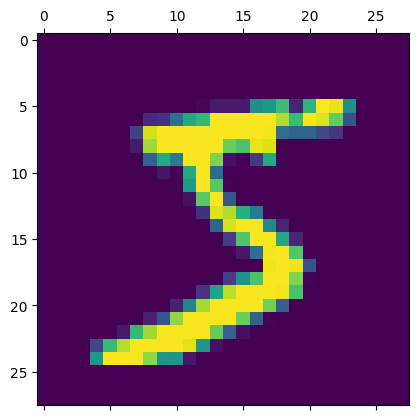

In [ ]:
plt.matshow(X_train[0]) # matrix show

In [62]:
y_train[0]

np.uint8(5)

In [63]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [64]:
X_train = X_train/255 # !important 
X_test = X_test/255

In [65]:
X_train_flattened = X_train.reshape(X_train.shape[0], 28 * 28 )
X_test_flattened = X_test.reshape(X_test.shape[0], 28 * 28 )

In [66]:
X_train_flattened.shape

(60000, 784)

In [67]:
X_train_flattened[0] # from 2d to 1d

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
model = keras.Sequential([ # stack of neural networks 
    # output is 10 (maybe is the input of the next layer), intput node count = 784
    keras.layers.Dense(10, input_shape=(784, ), activation='sigmoid')
])

model.compile(optimizer='adam', 
              # sparse: because the output variable (y_label) is actually an integer number
              # if it is onehot encoded array => use categorical_crossentropy
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8767 - loss: 0.4682
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9146 - loss: 0.3038
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9202 - loss: 0.2834
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9233 - loss: 0.2735
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9259 - loss: 0.2668


In [69]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9260 - loss: 0.2669


[0.26694756746292114, 0.9259999990463257]

In [ ]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0] # probabilities for 10 classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([1.9642301e-02, 2.2937932e-07, 3.2335095e-02, 9.4494486e-01,
       2.3898452e-03, 1.1435351e-01, 8.5485595e-07, 9.9972779e-01,
       8.9236952e-02, 6.8453288e-01], dtype=float32)

In [72]:
np.argmax(y_predicted[0])

np.int64(7)

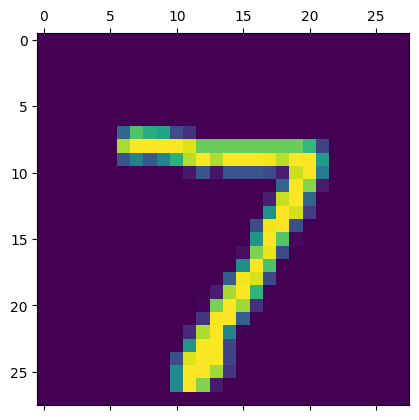

In [71]:
plt.matshow(X_test[0])

In [75]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]


In [78]:
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [79]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [77]:
cm = tf.math.confusion_matrix(y_test, y_predicted_labels)
cm 

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 959,    0,    1,    2,    0,    6,    6,    2,    4,    0],
       [   0, 1109,    3,    2,    0,    1,    4,    2,   14,    0],
       [   7,    9,  918,   19,    7,    4,   11,   10,   44,    3],
       [   3,    0,   13,  931,    0,   16,    2,   12,   26,    7],
       [   1,    1,    4,    1,  918,    0,    9,    4,   11,   33],
       [  10,    3,    3,   39,   10,  765,   16,    6,   34,    6],
       [  12,    3,    7,    1,    8,   11,  910,    2,    4,    0],
       [   1,    5,   21,    6,    9,    1,    0,  944,    6,   35],
       [   4,    6,    6,   18,    9,   19,    7,    8,  891,    6],
       [  10,    5,    1,   11,   27,    5,    0,   23,   12,  915]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

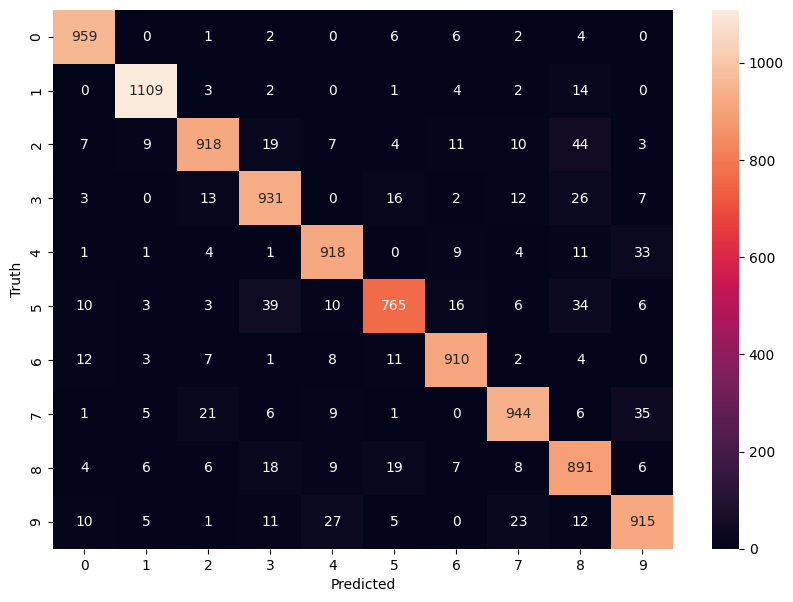

In [83]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d') # anything that is not in the diagonal is the error
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784, ), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid') # adding more hidden layers tends to imporve the performance
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs = 5)

c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9207 - loss: 0.2733
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9631 - loss: 0.1258
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9736 - loss: 0.0882
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9791 - loss: 0.0680
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9841 - loss: 0.0516


In [85]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9764 - loss: 0.0762


[0.07616365700960159, 0.9764000177383423]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


Text(95.72222222222221, 0.5, 'Truth')

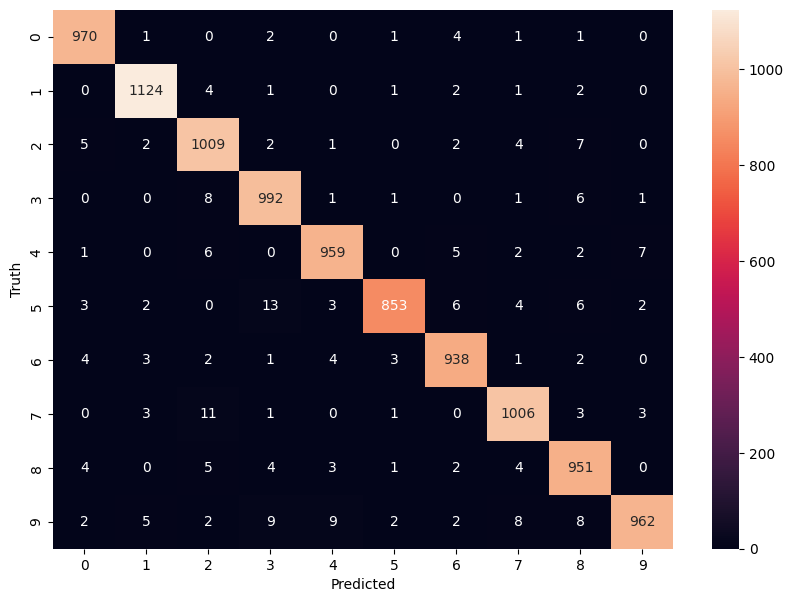

In [ ]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(y_test, y_predicted_labels)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d') # anything that is not in the diagonal is the error
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [ ]:
# if don't want to flatten input before training
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, activation='relu'),  # in case, don't know what activation function to use, go with relu
    keras.layers.Dense(10, activation='sigmoid') # adding more hidden layers tends to imporve the performance
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', # learning_rate usually = 0.01, w1 = w1 - learning rate.deriative(y(x1))
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs = 5)

c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9236 - loss: 0.2702
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9626 - loss: 0.1266
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9731 - loss: 0.0908
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9791 - loss: 0.0696
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9829 - loss: 0.0551


In [89]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9734 - loss: 0.0859


[0.0859295129776001, 0.9733999967575073]

In [90]:
y_predicted = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
